# ARCH Technologies Internship - Task 2-Traffic Signs Recognition.
Using a dataset of traffic sign images, build a computer vision model to recognize
and classify different traffic signs such as stop, yield, or speed limit signs.
Preprocess the images, train a convolutional neural network (CNN), and evaluate its
accuracy in correctly identifying the signs.

# 1) Imports and configuration

In [1]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import seaborn as sns

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from sklearn.metrics import confusion_matrix, classification_report

In [2]:
from google.colab import files
uploaded = files.upload()

Saving data.zip to data.zip


In [7]:
!unzip -q data.zip -d /content/data

replace /content/data/data/0/0_10000_1577671998.6491628.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/data/0/0_10001_1577671998.65016.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/data/data/0/0_10002_1577671998.65016.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

# 2) Data Loading and Exploration

In [8]:
DATASET_DIR = r"/content/data/data"

valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')

# Convert images to RGB if needed
for class_name in os.listdir(DATASET_DIR):
    class_path = os.path.join(DATASET_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if not img_file.lower().endswith(valid_ext):
            continue
        img_path = os.path.join(class_path, img_file)
        try:
            img = Image.open(img_path)
            if img.mode in ('P', 'LA', 'RGBA'):
                img = img.convert('RGB')
                img.save(img_path)
                print(f"Converted {img_path} to RGB")
        except Exception as e:
            print(f"Error processing {img_path}: {e}")


## Traffic Signs List (0 - 42)

In [9]:
traffic_signs = [
    {"id": 0, "name": "Speed Limit 20"},
    {"id": 1, "name": "Speed Limit 30"},
    {"id": 2, "name": "Speed Limit 50"},
    {"id": 3, "name": "Speed Limit 60"},
    {"id": 4, "name": "Speed Limit 70"},
    {"id": 5, "name": "Speed Limit 80"},
    {"id": 6, "name": "Speed Limit 80 (Overtaking Prohibited)"},
    {"id": 7, "name": "Speed Limit 100"},
    {"id": 8, "name": "Speed Limit 120"},
    {"id": 9, "name": "Speed Limit 120 (Vehicles with Passengers)"},
    {"id": 10, "name": "Speed Limit 120 (Vehicles with Trucks)"},
    {"id": 11, "name": "Intersection with Priority Road"},
    {"id": 12, "name": "Caution (Yellow Diamond)"},
    {"id": 13, "name": "Yield"},
    {"id": 14, "name": "Stop"},
    {"id": 15, "name": "Truck Prohibited"},
    {"id": 16, "name": "Heavy Vehicles Prohibited"},
    {"id": 17, "name": "Warning (Exclamation)"},
    {"id": 18, "name": "Sharp Turn Left"},
    {"id": 19, "name": "Sharp Turn Right"},
    {"id": 20, "name": "Hilly Road"},
    {"id": 21, "name": "Curve Ahead"},
    {"id": 22, "name": "Construction Zone"},
    {"id": 23, "name": "Pedestrian Crossing"},
    {"id": 24, "name": "Road Works"},
    {"id": 25, "name": "Traffic Signal Ahead"},
    {"id": 26, "name": "Pedestrian Crossing (With Lights)"},
    {"id": 27, "name": "Cyclist Path"},
    {"id": 28, "name": "Crosswalk"},
    {"id": 29, "name": "Bicycle Route"},
    {"id": 30, "name": "Emergency Vehicle"},
    {"id": 31, "name": "Wildlife Crossing"},
    {"id": 32, "name": "No Overtaking"},
    {"id": 33, "name": "Left Turn Only"},
    {"id": 34, "name": "Right Turn Only"},
    {"id": 35, "name": "Straight Ahead"},
    {"id": 36, "name": "T-junction (Right Turn)"},
    {"id": 37, "name": "Roundabout Ahead"},
    {"id": 38, "name": "One-Way Street (Right)"},
    {"id": 39, "name": "One-Way Street (Left)"},
    {"id": 40, "name": "Truck Route"},
    {"id": 41, "name": "Truck Stop"},
    {"id": 42, "name": "Heavy Vehicle Only (Truck Route)"}
]

# 3) Data Preprocessing

In [10]:
#Set image size and batch size
IMG_SIZE = (32, 32)
BATCH_SIZE = 32
SEED = 42

# Data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=False,
    fill_mode='nearest',
    validation_split=0.2
)

# Key Fix: Sort class folders numerically
class_folders = sorted(os.listdir(DATASET_DIR), key=lambda x: int(x))  # Sort by integer value

# Create generators with correct class order
train_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_folders,  # This forces numerical order
    subset='training',
    seed=SEED
)

val_generator = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_folders,  # This forces numerical order
    subset='validation',
    seed=SEED
)




Found 27840 images belonging to 43 classes.
Found 6959 images belonging to 43 classes.


In [11]:
# Save Mapping
class_indices = train_generator.class_indices
inv_map = {v: traffic_signs[int(k)]["name"] for k, v in class_indices.items()}

with open("class_indices.json", "w") as f:
    json.dump(inv_map, f)

print("✅ Classes mapped successfully:\n", inv_map)

✅ Classes mapped successfully:
 {0: 'Speed Limit 20', 1: 'Speed Limit 30', 2: 'Speed Limit 50', 3: 'Speed Limit 60', 4: 'Speed Limit 70', 5: 'Speed Limit 80', 6: 'Speed Limit 80 (Overtaking Prohibited)', 7: 'Speed Limit 100', 8: 'Speed Limit 120', 9: 'Speed Limit 120 (Vehicles with Passengers)', 10: 'Speed Limit 120 (Vehicles with Trucks)', 11: 'Intersection with Priority Road', 12: 'Caution (Yellow Diamond)', 13: 'Yield', 14: 'Stop', 15: 'Truck Prohibited', 16: 'Heavy Vehicles Prohibited', 17: 'Warning (Exclamation)', 18: 'Sharp Turn Left', 19: 'Sharp Turn Right', 20: 'Hilly Road', 21: 'Curve Ahead', 22: 'Construction Zone', 23: 'Pedestrian Crossing', 24: 'Road Works', 25: 'Traffic Signal Ahead', 26: 'Pedestrian Crossing (With Lights)', 27: 'Cyclist Path', 28: 'Crosswalk', 29: 'Bicycle Route', 30: 'Emergency Vehicle', 31: 'Wildlife Crossing', 32: 'No Overtaking', 33: 'Left Turn Only', 34: 'Right Turn Only', 35: 'Straight Ahead', 36: 'T-junction (Right Turn)', 37: 'Roundabout Ahead', 3

# 4) Model Architecture

In [12]:
input_shape = (32, 32, 3)
num_classes = len(class_indices)

model = Sequential([
    # First Convolutional Block
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=input_shape),
    BatchNormalization(),
    Conv2D(32, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Second Convolutional Block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Third Convolutional Block
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D(2, 2),
    Dropout(0.25),

    # Fully Connected Layers
    Flatten(),
    Dense(512, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(num_classes, activation='softmax')
])



/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer=Adam(learning_rate=1e-4),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     1,049,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 43)             │        11,051 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,481,419 (5.65 MB)

 Trainable params: 1,479,947 (5.65 MB)

 Non-trainable params: 1,472 (5.75 KB)

# 5) Callbacks and training

In [14]:
early = EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True, verbose=1)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-7, verbose=1)

EPOCHS = 50

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=[early, reduce_lr]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


870/870 ━━━━━━━━━━━━━━━━━━━━ 50s 43ms/step - accuracy: 0.0559 - loss: 4.5521 - val_accuracy: 0.1752 - val_loss: 3.0748 - learning_rate: 1.0000e-04
Epoch 2/50
870/870 ━━━━━━━━━━━━━━━━━━━━ 38s 44ms/step - accuracy: 0.1279 - loss: 3.4506 - val_accuracy: 0.2529 - val_loss: 2.6435 - learning_rate: 1.0000e-04
Epoch 3/50
870/870 ━━━━━━━━━━━━━━━━━━━━ 38s 43ms/step - accuracy: 0.2285 - loss: 2.8734 - val_accuracy: 0.3756 - val_loss: 2.0826 - learning_rate: 1.0000e-04
Epoch 4/50
870/870 ━━━━━━━━━━━━━━━━━━━━ 34s 39ms/step - accuracy: 0.3200 - loss: 2.3700 - val_accuracy: 0.4356 - val_loss: 1.7799 - learning_rate: 1.0000e-04
Epoch 5/50
870/870 ━━━━━━━━━━━━━━━━━━━━ 37s 43ms/step - accuracy: 0.3980 - loss: 1.9794 - val_accuracy: 0.5251 - val_loss: 1.4741 - learning_rate: 1.0000e-04
Epoch 6/50
870/870 ━━━━━━━━━━━━━━━━━━━━ 33s 38ms/step - accuracy: 0.4551 - loss: 1.7188 - val_accuracy: 0.6020 - val_loss: 1.2899 - learning_rate: 1.0000e-04
Epoch 7/50
870/870 ━━━━━━━━━━━━━━━━━━━━ 35s 40ms/step - accurac

# 6) Evaluate on validation set (best model saved as Traffic_signs_detector.h5)

In [15]:
model.save('Traffic_signs_detector.h5')
print("Model saved successfully!")
val_loss, val_acc = model.evaluate(val_generator)

Model saved successfully!
218/218 ━━━━━━━━━━━━━━━━━━━━ 6s 29ms/step - accuracy: 0.9866 - loss: 0.0449


In [16]:
# Use the trained model directly — no need to
best_model = model
val_loss, val_acc = model.evaluate(val_generator)
print(f"Validation loss: {val_loss:.4f} - Validation accuracy: {val_acc:.4f}")

218/218 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - accuracy: 0.9878 - loss: 0.0359
Validation loss: 0.0356 - Validation accuracy: 0.9886


# 7) Plot training history (loss & accuracy)

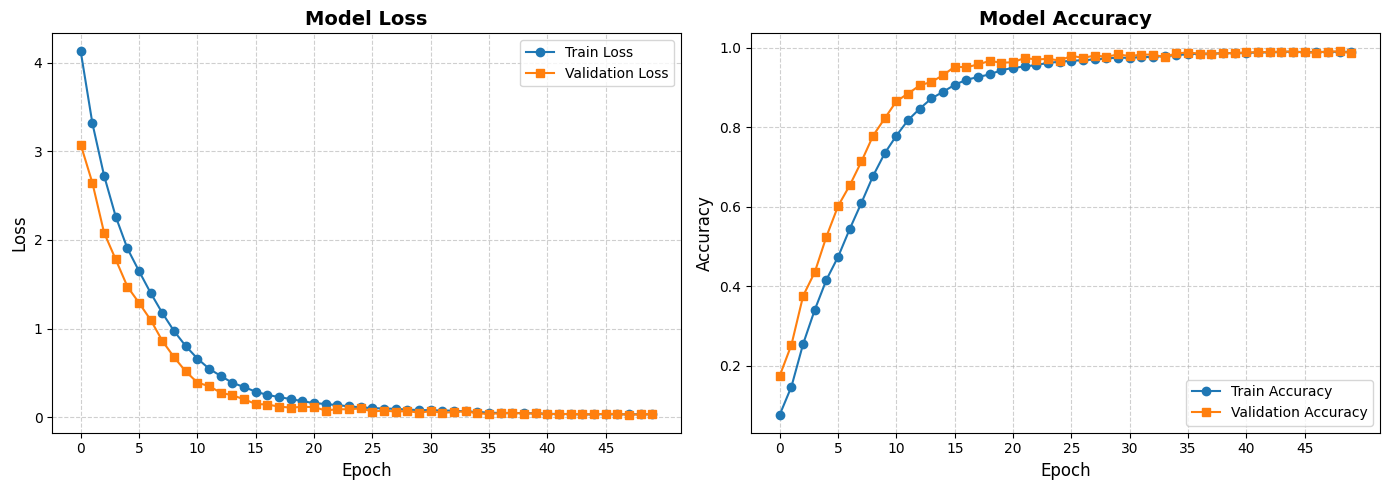

In [17]:
import matplotlib.pyplot as plt

# Get number of epochs actually trained (in case EarlyStopping stopped it early)
epochs_trained = len(history.history['loss'])

plt.figure(figsize=(14, 5))

# Plot 1: Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='s')
plt.title('Model Loss', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.xticks(range(0, epochs_trained, max(1, epochs_trained//10)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

# Plot 2: Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s')
plt.title('Model Accuracy', fontsize=14, fontweight='bold')
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(range(0, epochs_trained, max(1, epochs_trained//10)))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# 8) Confusion matrix and classification report

218/218 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step


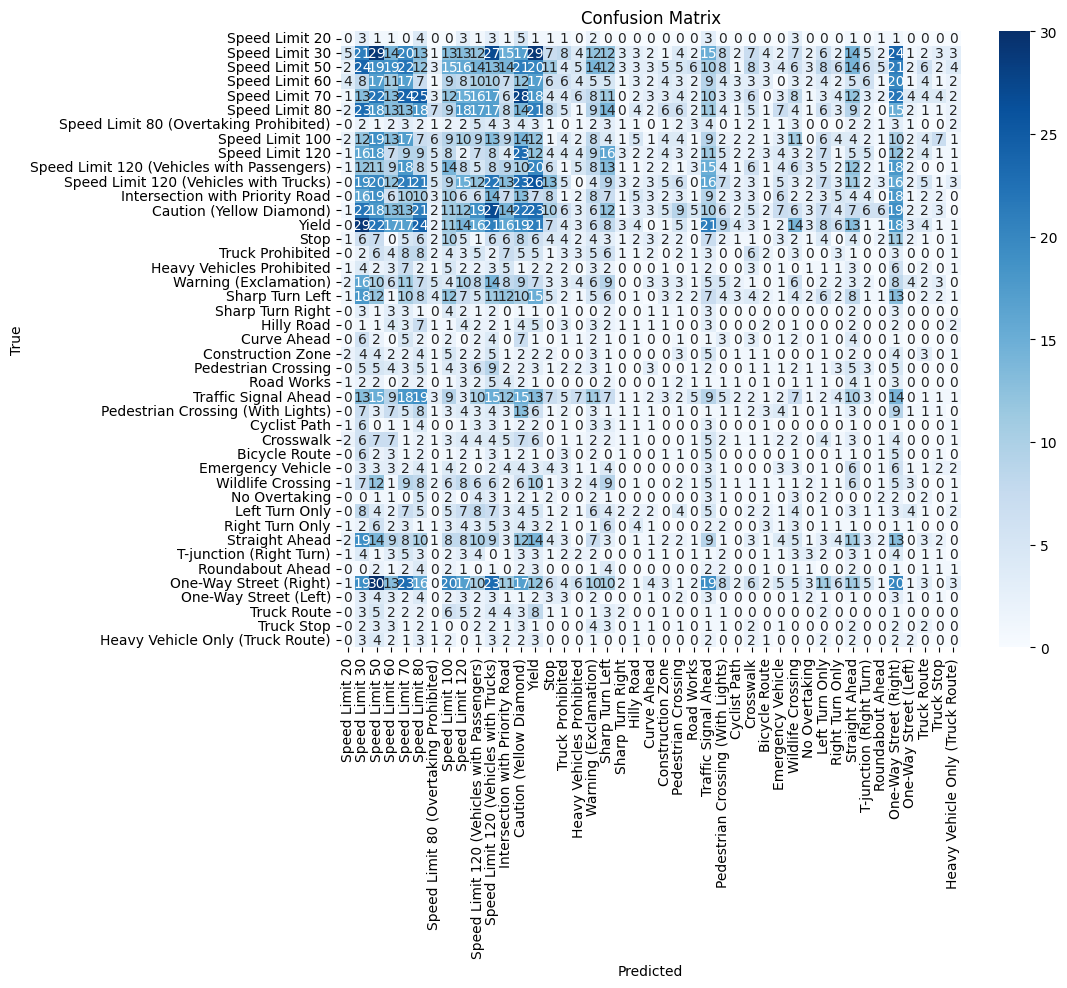


Classification Report:

                                            precision    recall  f1-score   support

                            Speed Limit 20       0.00      0.00      0.00        36
                            Speed Limit 30       0.05      0.05      0.05       396
                            Speed Limit 50       0.05      0.05      0.05       402
                            Speed Limit 60       0.04      0.04      0.04       252
                            Speed Limit 70       0.07      0.07      0.07       354
                            Speed Limit 80       0.05      0.05      0.05       330
    Speed Limit 80 (Overtaking Prohibited)       0.01      0.01      0.01        72
                           Speed Limit 100       0.03      0.03      0.03       258
                           Speed Limit 120       0.01      0.01      0.01       252
Speed Limit 120 (Vehicles with Passengers)       0.02      0.02      0.02       264
    Speed Limit 120 (Vehicles with Trucks)       0

In [18]:
# Predict classes (not binary!)
y_pred = best_model.predict(val_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[inv_map[i] for i in range(len(inv_map))],
            yticklabels=[inv_map[i] for i in range(len(inv_map))])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print("\nClassification Report:\n")
print(classification_report(y_true, y_pred_classes,
                            target_names=[inv_map[i] for i in range(len(inv_map))]))

# 9) Show sample images with predictions

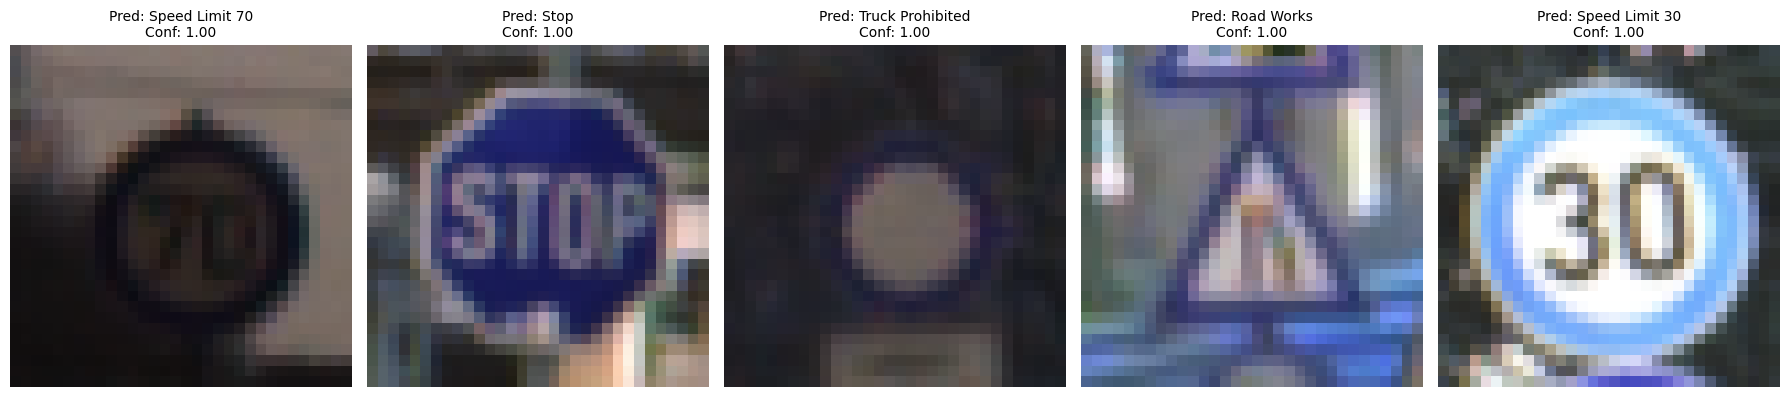

In [24]:
import random

# Get random sample from validation set
sample_paths = random.sample(val_generator.filepaths, min(5, len(val_generator.filepaths)))

fig, axes = plt.subplots(1, len(sample_paths), figsize=(18, 6))

for i, path in enumerate(sample_paths):
    # Load and preprocess image
    img = Image.open(path).convert('RGB').resize(IMG_SIZE)
    img_array = np.array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    # Predict
    pred_probs = best_model.predict(img_array, verbose=0)[0]
    pred_class_idx = np.argmax(pred_probs)
    pred_label = inv_map[pred_class_idx]
    confidence = pred_probs[pred_class_idx]

    # Display
    axes[i].imshow(Image.open(path))
    axes[i].axis('off')
    axes[i].set_title(f"Pred: {pred_label}\nConf: {confidence:.2f}", fontsize=10)

plt.tight_layout()
plt.show()


# 10) Single image prediction function

In [27]:
def predict_image(image_path, model_path='/content/Traffic_signs_detector.h5', img_size=(32, 32), show_image=True):
    """Load model, prepare image, predict, and optionally show image with prediction."""
    try:
        # Load model
        model = load_model(model_path)

        # Load class mapping
        with open('/content/class_indices.json', 'r') as f:
            inv_map = json.load(f)
        inv_map = {int(k): v for k, v in inv_map.items()}  # Convert keys to int

        # Prepare image
        img = Image.open(image_path).convert('RGB')
        img_resized = img.resize(img_size)
        arr = np.array(img_resized) / 255.0
        arr = np.expand_dims(arr, axis=0)

        # Predict
        pred_probs = model.predict(arr)[0]
        predicted_index = np.argmax(pred_probs)
        predicted_label = inv_map[predicted_index]
        confidence = float(pred_probs[predicted_index])

        # Show image if requested
        if show_image:
            plt.figure(figsize=(6, 6))
            plt.imshow(img)  # Show original image
            plt.axis('off')
            plt.title(f"Prediction: {predicted_label}\nConfidence: {confidence:.2f}", fontsize=12, fontweight='bold')
            plt.show()

        return {
            'label': predicted_label,
            'confidence': confidence,
            'predicted_class_index': int(predicted_index),
            'all_probabilities': pred_probs.tolist()
        }

    except FileNotFoundError as e:
        return {"error": f"File not found: {str(e)}"}
    except Exception as e:
        return {"error": f"Prediction failed: {str(e)}"}


# 11) Test Image

Testing on image: /content/data/data/33/33_26827_1577672014.3759873.png


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 677ms/step


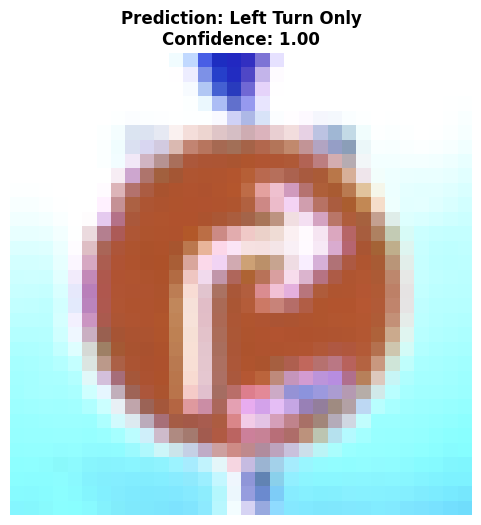

{'label': 'Left Turn Only', 'confidence': 1.0, 'predicted_class_index': 33, 'all_probabilities': [4.2086157590892365e-15, 1.3485073679042403e-18, 5.503534106104956e-16, 7.565108749944122e-14, 5.486871485724807e-15, 1.012066136191897e-14, 2.0758454814042852e-17, 1.4880481693851574e-14, 4.459210244776184e-16, 6.496155881014626e-14, 2.6018521104981263e-13, 8.69052826032707e-18, 6.503022660650986e-18, 4.4818646406999396e-13, 3.5429867851530905e-20, 1.1503121588943288e-12, 2.3467316736641144e-15, 1.9760160311254655e-17, 1.451474603759688e-18, 2.954257028887417e-17, 1.2913033374517807e-14, 1.8808418551063965e-19, 8.006083643263828e-12, 6.975956889305524e-17, 8.605572210225716e-20, 3.8274387269476825e-18, 8.62954982905864e-17, 2.3829877408302667e-22, 1.9726623927679918e-19, 1.1489957261751506e-17, 2.5402555311284032e-18, 4.462526577288032e-17, 8.300382950410246e-13, 1.0, 7.117930377054105e-13, 5.840447570015783e-10, 3.666548401698444e-13, 2.7410953281487016e-12, 1.6436395159410283e-13, 9.3785

In [42]:
import random

# Pick a random class folder
class_folder = random.choice(os.listdir(data_path))

# Pick a random image inside that folder
class_path = os.path.join(data_path, class_folder)
image_file = random.choice(os.listdir(class_path))
test_image_path = os.path.join(class_path, image_file)

print("Testing on image:", test_image_path)

# Run prediction
result = predict_image(test_image_path)
print(result)
